170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2221s 13us/step
Training Data Shape: (50000, 32, 32, 3)
Testing Data Shape: (10000, 32, 32, 3)
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.3098 - loss: 1.9204 - val_accuracy: 0.3408 - val_loss: 1.8503
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 12s 33ms/step - accuracy: 0.3872 - loss: 1.7241 - val_accuracy: 0.4030 - val_loss: 1.6825
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.4145 - loss: 1.6369 - val_accuracy: 0.4148 - val_loss: 1.6502
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.4344 - loss: 1.5812 - val_accuracy: 0.4036 - val_loss: 1.6437
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.4455 - loss: 1.5515 - val_accuracy: 0.4512 - val_loss: 1.5504
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4613 - loss: 1.5110 - val_accuracy: 0.4470 - val_loss: 1.5524
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.4693 - loss: 1.4830 -

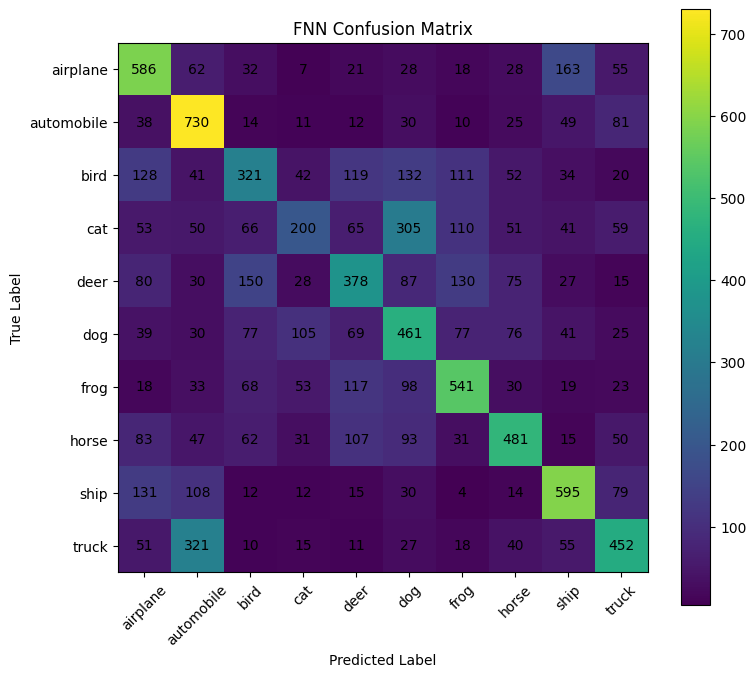

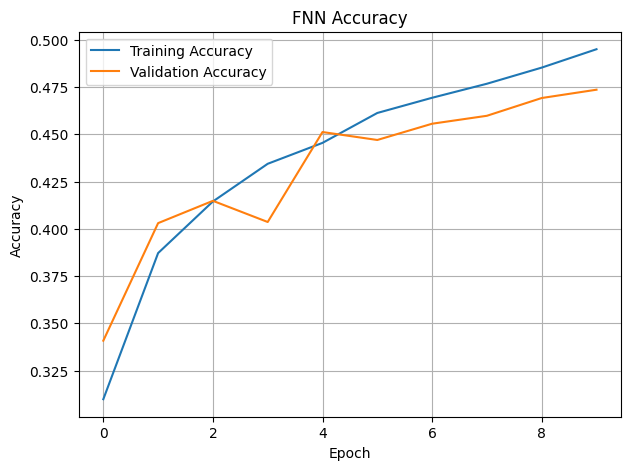

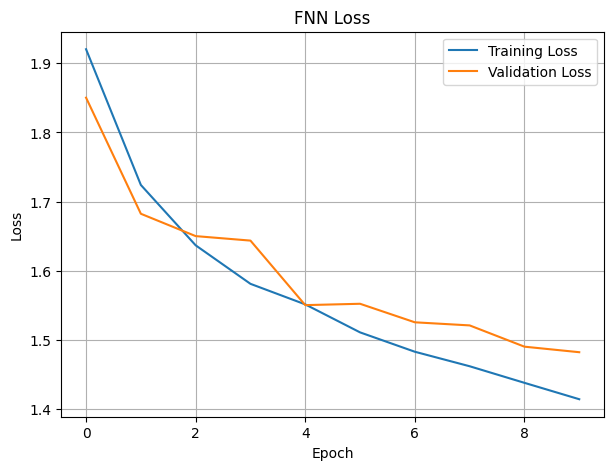

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 63s 172ms/step - accuracy: 0.4150 - loss: 1.6002 - val_accuracy: 0.5274 - val_loss: 1.3128
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 172ms/step - accuracy: 0.5529 - loss: 1.2513 - val_accuracy: 0.5886 - val_loss: 1.1810
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 60s 172ms/step - accuracy: 0.6106 - loss: 1.0964 - val_accuracy: 0.6478 - val_loss: 1.0237
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 61s 173ms/step - accuracy: 0.6538 - loss: 0.9863 - val_accuracy: 0.6670 - val_loss: 0.9727
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 171ms/step - accuracy: 0.6869 - loss: 0.8932 - val_accuracy: 0.7002 - val_loss: 0.8828
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 60s 171ms/step - accuracy: 0.7128 - loss: 0.8224 - val_accuracy: 0.6858 - val_loss: 0.9003
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 82s 171ms/step - accuracy: 0.7390 - loss: 0.7511 - val_accuracy: 0.6978 - val_loss: 0.8943
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 63s 180ms/step - accuracy: 0.7552 - loss: 0

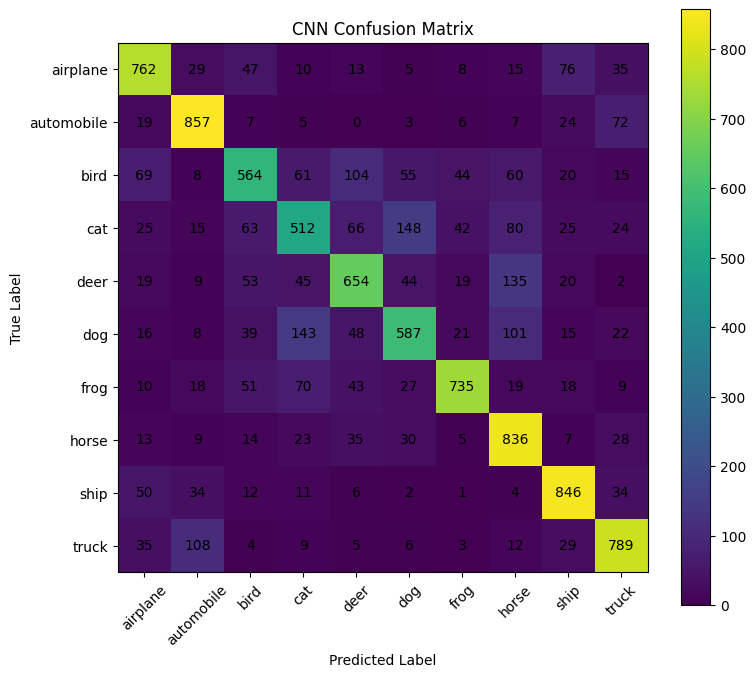

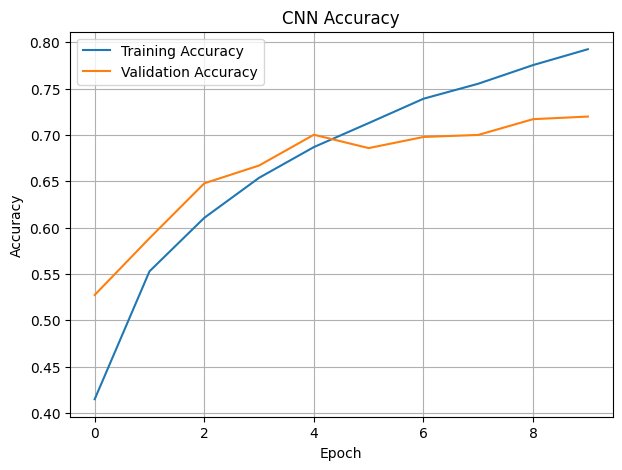

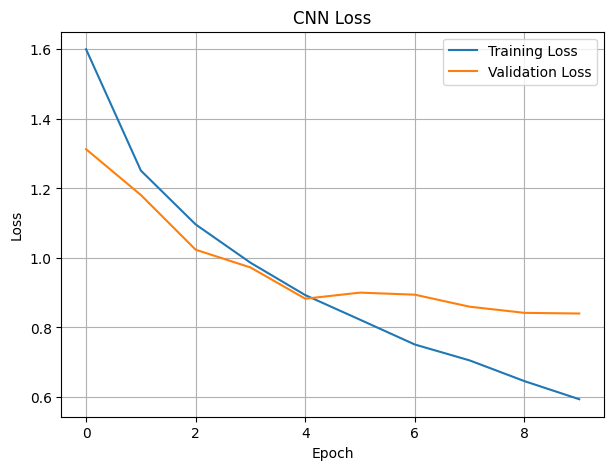

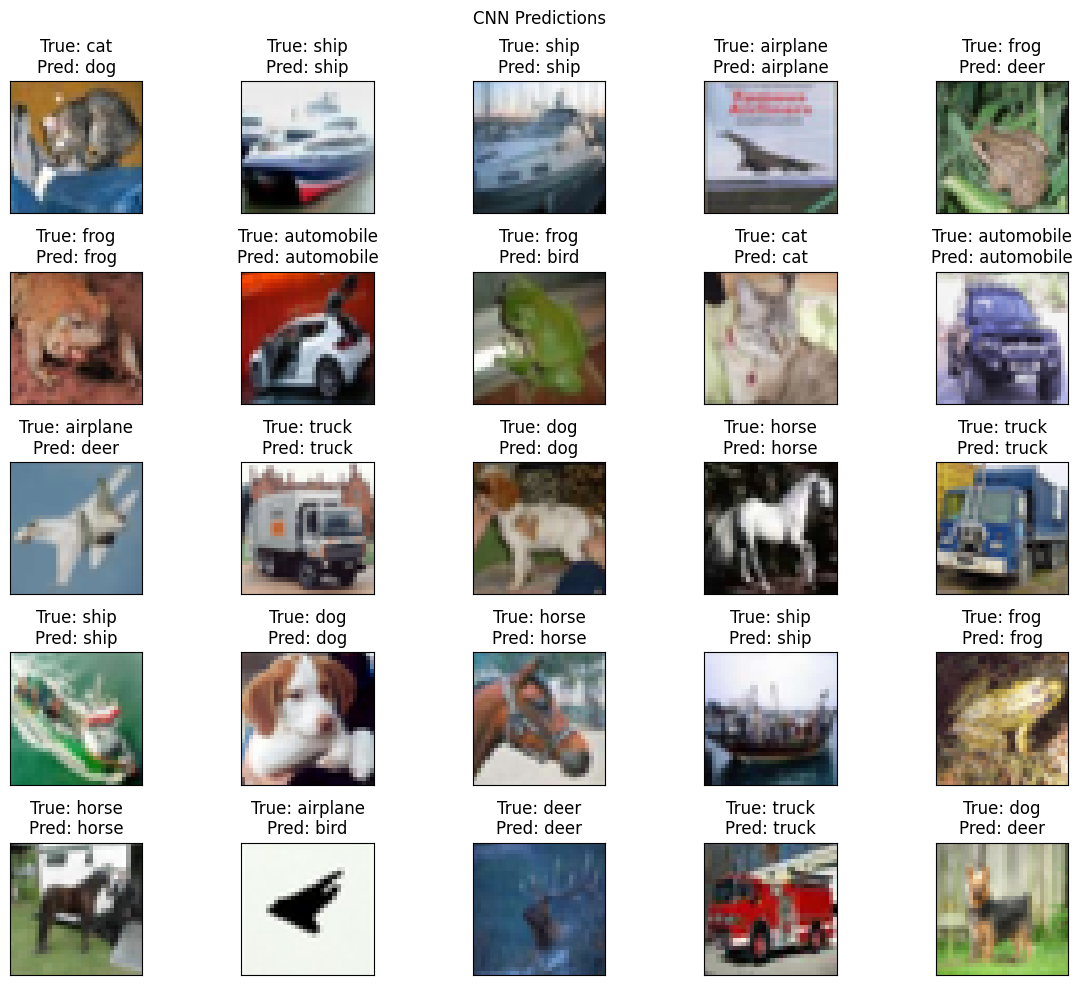


Final Comparison
FNN Accuracy: 47.45 %
CNN Accuracy: 71.42 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

y_train = y_train.flatten()
y_test = y_test.flatten()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Training Data Shape:", x_train.shape)
print("Testing Data Shape:", x_test.shape)


# FNN

x_train_fnn = x_train.reshape(-1, 3072)
x_test_fnn = x_test.reshape(-1, 3072)

model_fnn = keras.Sequential([
    layers.Input(shape=(3072,)),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_fnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_fnn = model_fnn.fit(
    x_train_fnn,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

loss_fnn, accuracy_fnn = model_fnn.evaluate(
    x_test_fnn,
    y_test,
    verbose=0
)

print("\nFNN Test Loss:", round(loss_fnn, 4))
print("FNN Test Accuracy:", round(accuracy_fnn, 4))


# FNN Classification Report

y_pred_fnn = np.argmax(
    model_fnn.predict(x_test_fnn, verbose=0),
    axis=1
)

print("\nFNN Classification Report")
print(
    classification_report(
        y_test,
        y_pred_fnn,
        target_names=class_names
    )
)


# FNN Confusion Matrix

cm_fnn = confusion_matrix(y_test, y_pred_fnn)

plt.figure(figsize=(8, 7))
plt.imshow(cm_fnn)

plt.title("FNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm_fnn[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# FNN Accuracy

plt.figure(figsize=(7, 5))

plt.plot(
    history_fnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_fnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("FNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()


# FNN Loss

plt.figure(figsize=(7, 5))

plt.plot(
    history_fnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_fnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("FNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()


# CNN

model_cnn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_cnn = model_cnn.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

loss_cnn, accuracy_cnn = model_cnn.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nCNN Test Loss:", round(loss_cnn, 4))
print("CNN Test Accuracy:", round(accuracy_cnn, 4))


# CNN Classification Report

y_pred_cnn = np.argmax(
    model_cnn.predict(x_test, verbose=0),
    axis=1
)

print("\nCNN Classification Report")

print(
    classification_report(
        y_test,
        y_pred_cnn,
        target_names=class_names
    )
)


# CNN Confusion Matrix

cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(8, 7))

plt.imshow(cm_cnn)

plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

for i in range(10):
    for j in range(10):
        plt.text(
            j,
            i,
            cm_cnn[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()


# CNN Accuracy

plt.figure(figsize=(7, 5))

plt.plot(
    history_cnn.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_cnn.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()


# CNN Loss

plt.figure(figsize=(7, 5))

plt.plot(
    history_cnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn.history["val_loss"],
    label="Validation Loss"
)

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()


# CNN Sample Predictions

plt.figure(figsize=(12, 10))

for i in range(25):

    plt.subplot(5, 5, i + 1)

    plt.imshow(x_test[i])

    actual = class_names[y_test[i]]
    predicted = class_names[y_pred_cnn[i]]

    plt.title(
        "True: " + actual +
        "\nPred: " + predicted
    )

    plt.xticks([])
    plt.yticks([])

plt.suptitle("CNN Predictions")
plt.tight_layout()
plt.show()


# Final Comparison

print("\nFinal Comparison")

print(
    "FNN Accuracy:",
    round(accuracy_fnn * 100, 2),
    "%"
)

print(
    "CNN Accuracy:",
    round(accuracy_cnn * 100, 2),
    "%"
)